In [26]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

In [28]:
image_obj = nib.load("data/BraTS-Africa/95_Glioma/BraTS-SSA-00007-000/BraTS-SSA-00007-000-t1c.nii.gz")
label_obj = nib.load("data/BraTS-Africa/95_Glioma/BraTS-SSA-00007-000/BraTS-SSA-00007-000-seg.nii.gz")

image_data = image_obj.get_fdata()
label_L = label_obj.get_fdata()

print(f"Dados prontos para o Step 3. Shape: {image_data.shape}")

Dados prontos para o Step 3. Shape: (240, 240, 155)


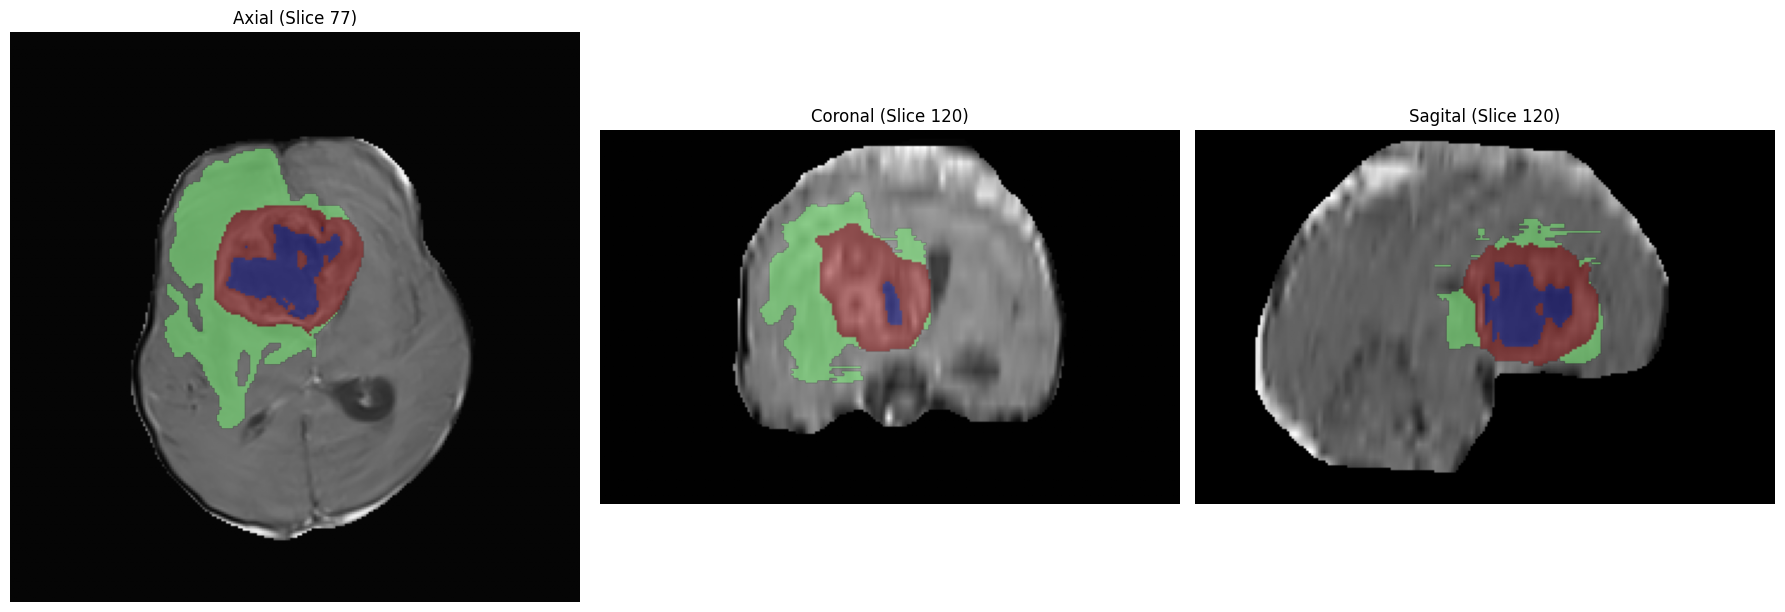

In [29]:
mid_x = image_data.shape[0] // 2
mid_y = image_data.shape[1] // 2
mid_z = image_data.shape[2] // 2

masked_label = np.where(label_L == 0, np.nan, label_L)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Plano Axial (Z) ---
axes[0].imshow(image_data[:, :, mid_z].T, cmap='gray', origin='lower')
axes[0].imshow(masked_label[:, :, mid_z].T, cmap='jet', alpha=0.5, origin='lower')
axes[0].set_title(f'Axial (Slice {mid_z})')
axes[0].axis('off')

# --- Plano Coronal (Y) ---
axes[1].imshow(image_data[:, mid_y, :].T, cmap='gray', origin='lower')
axes[1].imshow(masked_label[:, mid_y, :].T, cmap='jet', alpha=0.5, origin='lower')
axes[1].set_title(f'Coronal (Slice {mid_y})')
axes[1].axis('off')

# --- Plano Sagital (X) ---
axes[2].imshow(image_data[mid_x, :, :].T, cmap='gray', origin='lower')
axes[2].imshow(masked_label[mid_x, :, :].T, cmap='jet', alpha=0.5, origin='lower')
axes[2].set_title(f'Sagital (Slice {mid_x})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

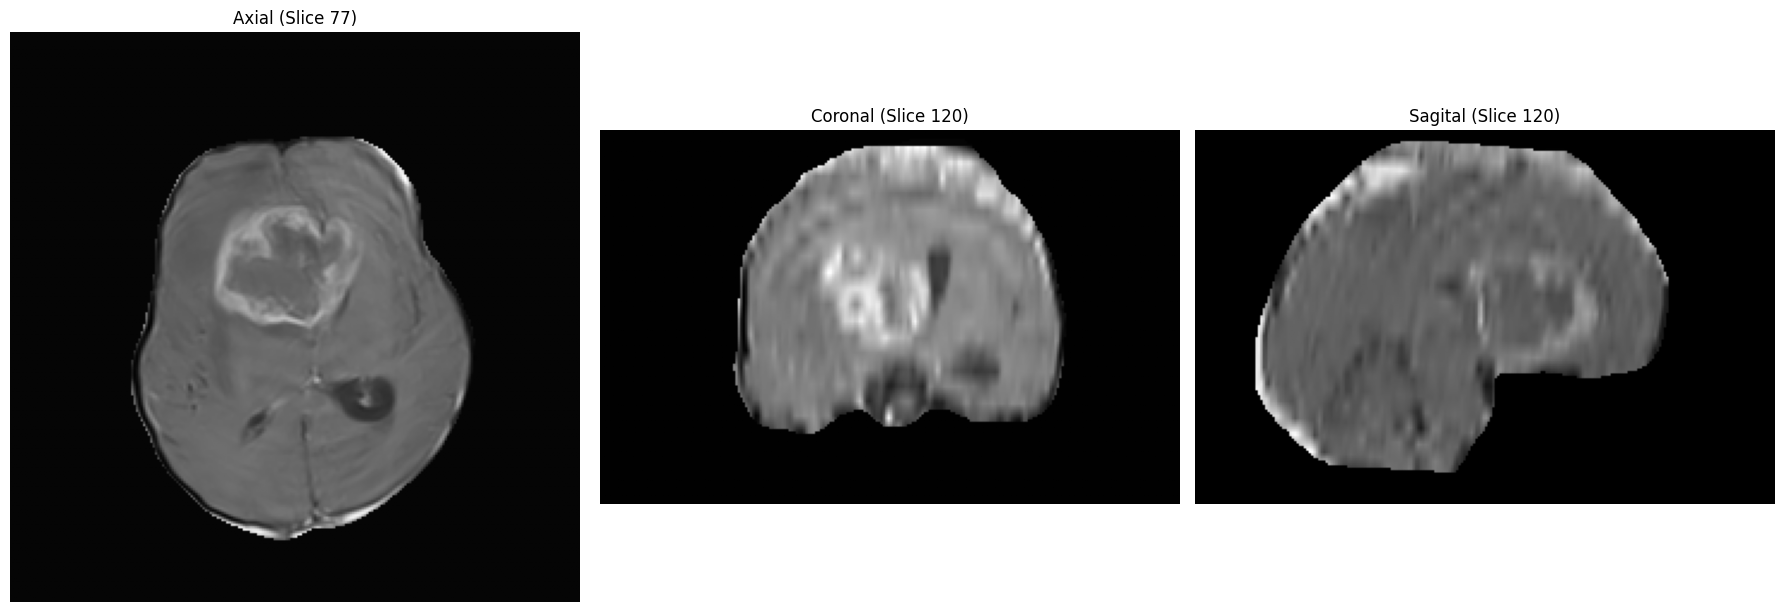

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Plano Axial (Z) ---
axes[0].imshow(image_data[:, :, mid_z].T, cmap='gray', origin='lower')
axes[0].set_title(f'Axial (Slice {mid_z})')
axes[0].axis('off')

# --- Plano Coronal (Y) ---
axes[1].imshow(image_data[:, mid_y, :].T, cmap='gray', origin='lower')
axes[1].set_title(f'Coronal (Slice {mid_y})')
axes[1].axis('off')

# --- Plano Sagital (X) ---
axes[2].imshow(image_data[mid_x, :, :].T, cmap='gray', origin='lower')
axes[2].set_title(f'Sagital (Slice {mid_x})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [35]:
def corrupt_segmentation(label, noise_prob=0.05):
  noisy = label.copy()
  mask = np.random.rand(*label.shape) < noise_prob
  noisy[mask] = np.random.randint(0, label.max()+1, size=mask.sum())
  return noisy

In [36]:
image_data = image_obj.get_fdata().astype(np.float32)
seg_gt = label_obj.get_fdata().astype(np.int32)

image_data = (image_data - image_data.min()) / (image_data.max() - image_data.min() + 1e-8)
image_data = (image_data * 255).astype(np.float32)

In [37]:
seg_init = corrupt_segmentation(label_L)

In [46]:
def save_scn(filename, volume, bits=16):
    z, y, x = volume.shape

    if bits == 8:
        volume = (volume - volume.min()) / (volume.max() - volume.min() + 1e-8)
        volume = (volume * 255).astype(np.uint8)

    elif bits == 16:
        volume = (volume - volume.min()) / (volume.max() - volume.min() + 1e-8)
        volume = (volume * 65535).astype(np.uint16)

    elif bits == 32:
        volume = volume.astype(np.int32)

    else:
        raise ValueError("bits must be 8, 16 or 32")

    with open(filename, "wb") as f:
        f.write(b"SCN\n")
        f.write(f"{x} {y} {z}\n".encode())
        f.write(b"1.0 1.0 1.0\n")
        f.write(f"{bits}\n".encode())  # 🔥 direto, sem "1"
        
        volume.tofile(f)

save_scn("init-seg/image.scn", image_data)
save_scn("init-seg/label_init.scn", seg_init)
save_scn("init-seg/label_gt.scn", seg_gt)